In [16]:
import json
import random

train_path = './datasets/GliNER/sample_data.json'
with open(train_path, 'r') as f:
    data = json.load(f)
print("Data Size: ", len(data))
train_dataset = data[:int(len(data)*0.9)]
test_dataset = data[int(len(data)*0.9):]

Data Size:  64


In [17]:
# /home/tuo96248/projects/NER-DAug/datasets/crossner/ai_train.json
with open('/home/tuo96248/projects/NER-DAug/datasets/crossner/ai_train.json', 'r') as f:
    ai = json.load(f)
print(ai[0].keys())

dict_keys(['str_words', 'tags_ner', 'tags_esi', 'tags_net', 'sent_id'])


In [11]:
print(ai[1]['str_words'])

['Advocates', 'of', 'procedural', 'representations', 'were', 'mainly', 'centered', 'at', 'MIT', ',', 'under', 'the', 'leadership', 'of', 'Marvin', 'Minsky', 'and', 'Seymour', 'Papert', '.']


In [12]:
print(ai[1]['tags_ner'])

['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-university', 'O', 'O', 'O', 'O', 'O', 'B-researcher', 'I-researcher', 'O', 'B-researcher', 'I-researcher', 'O']


In [14]:
for i, tag in enumerate(ai[1]['tags_ner']):
    print(i, tag)

0 O
1 O
2 O
3 O
4 O
5 O
6 O
7 O
8 B-university
9 O
10 O
11 O
12 O
13 O
14 B-researcher
15 I-researcher
16 O
17 B-researcher
18 I-researcher
19 O


In [15]:
data[1]

{'tokenized_text': ['A',
  'message',
  'from',
  'Katarzyna',
  '…',
  'for',
  'September',
  '1',
  ',',
  '2014',
  '.'],
 'ner': [[3, 3, 'Person'], [6, 9, 'Date']]}

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from gliner import GLiNERConfig, GLiNER
from gliner.training import Trainer, TrainingArguments
from gliner.data_processing.collator import DataCollatorWithPadding, DataCollator
from gliner.utils import load_config_as_namespace
from gliner.data_processing import WordsSplitter, GLiNERDataset

/home/tuo96248/anaconda3/envs/scikg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
model = GLiNER.from_pretrained("urchade/gliner_base")

/home/tuo96248/anaconda3/envs/scikg/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [5]:
data_collator = DataCollator(model.config, data_processor=model.data_processor, prepare_labels = True)
model.to(device)
print("Model Loaded")

Model Loaded


In [ ]:
# calculate number of epochs
num_steps = 500
batch_size = 8
data_size = len(train_dataset)
num_batches = data_size // batch_size
num_epochs = max(1, num_steps // num_batches)

training_args = TrainingArguments(
    output_dir="./ckpts", # The trained model output directory
    learning_rate=5e-6,
    weight_decay=0.01,
    others_lr=1e-5,
    others_weight_decay=0.01,
    lr_scheduler_type="linear", #cosine
    warmup_ratio=0.1,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    focal_loss_alpha=0.75,
    focal_loss_gamma=2,
    num_train_epochs=num_epochs,
    evaluation_strategy="steps",
    save_steps = 100,
    save_total_limit=10,
    dataloader_num_workers = 0,
    use_cpu = False,
    report_to="none",
    )

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=model.data_processor.transformer_tokenizer,
    data_collator=data_collator,
)

trainer.train()

/home/tuo96248/anaconda3/envs/scikg/lib/python3.11/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_1084651/2059158933.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Step,Training Loss,Validation Loss
500,2.143400,102.031937


TrainOutput(global_step=568, training_loss=1.94826173110747, metrics={'train_runtime': 87.5723, 'train_samples_per_second': 46.213, 'train_steps_per_second': 6.486, 'total_flos': 0.0, 'train_loss': 1.94826173110747, 'epoch': 71.0})

### Evaluation

In [1]:
import json
import os
import random
import torch
import numpy as np
import argparse
from tqdm import tqdm

from gliner import GLiNERConfig, GLiNER
from gliner.training import Trainer, TrainingArguments
from gliner.data_processing.collator import DataCollatorWithPadding, DataCollator
from gliner.utils import load_config_as_namespace
from gliner.data_processing import WordsSplitter, GLiNERDataset
from typing import List, Tuple, Dict

os.environ["TOKENIZERS_PARALLELISM"] = "true" # This is required to avoid warning from transformers
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # This is required to avoid warning from transformers
# typing

def bio_to_spans(tags: List[str]) -> List[List[int]]:
    """
    Convert a sequence of BIO tags to a list of spans.
    Args:
        tags: A list of BIO tags.
    Returns:
        A list of spans, where each span is a list [start, end, type].
    """
    spans = []
    i = 0
    while i < len(tags):
        # Check for beginning of an entity.
        if tags[i].startswith("B-"):
            entity_type = tags[i][2:]
            start = i
            end = i
            i += 1
            # Continue for subsequent I-tags of the same type.
            while i < len(tags) and tags[i] == f"I-{entity_type}":
                end = i
                i += 1
            spans.append([start, end, entity_type])
        else:
            i += 1
    return spans

def read_data(data_path: str) -> List[Dict[List, List]]:
    """
    Read the training and test data from a file and convert it to GliNER format.
    Args:
        data_path: The path to the data file.
    Returns:
        A list of dictionaries, where each dictionary has the keys "tokenized_text" and "ner".
    """
    with open(data_path, "r") as f:
        data = json.load(f)
    new_data = []
    for item in data:
        ner = bio_to_spans(item["tags_ner"])
        new_data.append(
            {
                "tokenized_text": item["str_words"],
                "ner": ner,
            }
        )
    return new_data

def get_labels(data: List[Dict[List, List]]) -> List[str]:
    """
    Get the unique labels from the data.
    Args:
        data: The data in GliNER format.
    Returns:
        A list of unique labels.
    """
    labels = set()
    for item in data:
        for span in item["ner"]:
            labels.add(span[2])
    return list(labels)

def get_gts(tokenized_text, ner):
    gts = []
    for span in ner:
        start, end, label = span
        tokens = tokenized_text[start:end+1]
        text = " ".join(tokens)
        gts.append([text, label])
    return gts

/home/tuo96248/anaconda3/envs/scikg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Testing zero-shot models**

In [35]:
data_name = "politics"
shots = 0
ckpts_dir = "./ckpts/gliner/"

# load test data
test_path = f'./datasets/crossner/{data_name}_test.json'
test_data = read_data(test_path)
labels = get_labels(test_data)
print("Test Data Size: ", len(test_data))
print("Labels: ", labels)
model_path = ckpts_dir + f"{data_name}_checkpoint-{shots}"
output_dir = f"./output/gliner/{data_name}_{shots}"
os.makedirs(output_dir, exist_ok=True)
# Load the model and tokenizer.
trained_model = model = GLiNER.from_pretrained("urchade/gliner_base")
# test the data one by one
for item in tqdm(test_data):
    tokenized_text = item["tokenized_text"]
    ner = item["ner"]
    text = " ".join(tokenized_text)
    # Predict the NER spans.
    pred_ner = model.predict_entities(text, labels)
    # print("Predicted NER: ", pred_ner)
    # append to the test_data
    item["pred_ner"] = pred_ner
    item["gts"] = get_gts(tokenized_text, ner)
    item["preds"] = [[pred['text'], pred['label']] for pred in pred_ner]
# save the test_data
output_path = f"{output_dir}/{data_name}_test.json"
with open(output_path, "w") as f:
    json.dump(test_data, f, indent=2)
print("Test data saved to: ", output_path)

Test Data Size:  651
Labels:  ['election', 'politicalparty', 'politician', 'person', 'misc', 'location', 'event', 'country', 'organisation']


100%|██████████| 651/651 [00:45<00:00, 14.27it/s]

Test data saved to:  ./output/gliner/politics_0/politics_test.json


In [36]:
from collections import Counter
from utils import save_jsonl, load_jsonl, load_json, save_json, extract_entities, evaluate_sent, compute_f1
# output_path = "./output/gliner/music_0/music_test.json"
data = load_json(output_path)
counts = Counter()
for sent in data:
    pred = sent['preds']
    ref = sent['gts']
    counts = evaluate_sent(ref, pred, counts)
scores_ner = compute_f1(counts["ner_predicted"], counts["ner_gold"], counts["ner_matched"])
print("NER Scores: ", scores_ner)

NER Scores:  {'precision': 0.5706152835559448, 'recall': 0.6191494416726063, 'f1': 0.5938924339106654}


**Testing trained models**

In [9]:
data_name = "politics"
shots = [1, 10, 25, 50, 100]
for shot in shots:
    ckpts_dir = f"./ckpts/gliner/{data_name}_{shot}/"
    output_dir = f"./output/gliner/{data_name}_{shot}"
    os.makedirs(output_dir, exist_ok=True)

    # load test data
    test_path = f'./datasets/crossner/{data_name}_test.json'
    test_data = read_data(test_path)
    labels = get_labels(test_data)
    print("Test Data Size: ", len(test_data))
    print("Labels: ", labels)

    # Load the model and tokenizer.
    model_path = ckpts_dir + f"checkpoint-100"
    trained_model = GLiNER.from_pretrained(model_path, load_tokenizer=True)

    # test the data one by one
    for item in tqdm(test_data):
        tokenized_text = item["tokenized_text"]
        ner = item["ner"]
        text = " ".join(tokenized_text)
        # Predict the NER spans.
        pred_ner = trained_model.predict_entities(text, labels)
        # print("Predicted NER: ", pred_ner)
        # append to the test_data
        item["pred_ner"] = pred_ner
        item["gts"] = get_gts(tokenized_text, ner)
        item["preds"] = [[pred['text'], pred['label']] for pred in pred_ner]
    # save the test_data
    output_path = f"{output_dir}/{data_name}_test.json"
    with open(output_path, "w") as f:
        json.dump(test_data, f, indent=2)
    print("Test data saved to: ", output_path)
    # evaluation
    from collections import Counter
    from utils import save_jsonl, load_jsonl, load_json, save_json, extract_entities, evaluate_sent, compute_f1
    data = load_json(output_path)
    counts = Counter()
    for sent in data:
        pred = sent['preds']
        ref = sent['gts']
        counts = evaluate_sent(ref, pred, counts)
    scores_ner = compute_f1(counts["ner_predicted"], counts["ner_gold"], counts["ner_matched"])
    print(f" ====== {shot} ====== ")
    print("NER Scores: ", scores_ner)

config.json not found in /home/tuo96248/projects/NER-DAug/ckpts/gliner/politics_1/checkpoint-100


Test Data Size:  651
Labels:  ['misc', 'person', 'organisation', 'politician', 'country', 'event', 'election', 'politicalparty', 'location']


100%|██████████| 651/651 [00:48<00:00, 13.33it/s]
config.json not found in /home/tuo96248/projects/NER-DAug/ckpts/gliner/politics_10/checkpoint-100


Test data saved to:  ./output/gliner/politics_1/politics_test.json
 ====== 1 ====== 
NER Scores:  {'precision': 0.5917174796747967, 'recall': 0.5533380850558327, 'f1': 0.5718845917740945}
Test Data Size:  651
Labels:  ['misc', 'person', 'organisation', 'politician', 'country', 'event', 'election', 'politicalparty', 'location']


100%|██████████| 651/651 [00:49<00:00, 13.18it/s]
config.json not found in /home/tuo96248/projects/NER-DAug/ckpts/gliner/politics_25/checkpoint-100


...

Test data saved to:  ./output/gliner/politics_25/politics_test.json
 ====== 25 ====== 
NER Scores:  {'precision': 0.7612888052681092, 'recall': 0.7690662865288667, 'f1': 0.7651577827679943}
Test Data Size:  651
Labels:  ['misc', 'person', 'organisation', 'politician', 'country', 'event', 'election', 'politicalparty', 'location']


config.json not found in /home/tuo96248/projects/NER-DAug/ckpts/gliner/politics_50/checkpoint-100
100%|██████████| 651/651 [00:49<00:00, 13.20it/s]
config.json not found in /home/tuo96248/projects/NER-DAug/ckpts/gliner/politics_100/checkpoint-100


Test data saved to:  ./output/gliner/politics_50/politics_test.json
 ====== 50 ====== 
NER Scores:  {'precision': 0.7292993630573248, 'recall': 0.7617011166547873, 'f1': 0.7451481696687972}
Test Data Size:  651
Labels:  ['misc', 'person', 'organisation', 'politician', 'country', 'event', 'election', 'politicalparty', 'location']


100%|██████████| 651/651 [00:49<00:00, 13.21it/s]

Test data saved to:  ./output/gliner/politics_100/politics_test.json
 ====== 100 ====== 
NER Scores:  {'precision': 0.7268100855887115, 'recall': 0.7464956046566881, 'f1': 0.7365213314580402}


### Plot figures

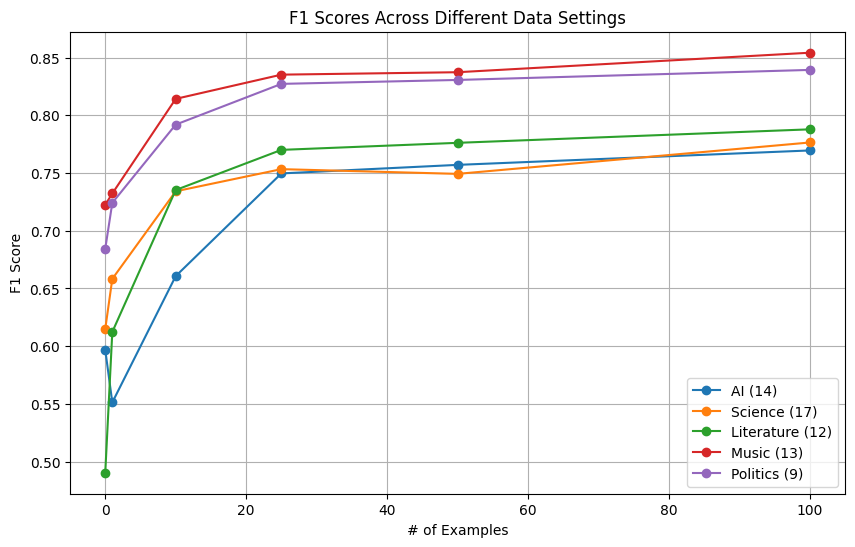

In [11]:
import matplotlib.pyplot as plt

def plot_f1_scores():
    # Data from the table
    data_setting = [0, 1, 10, 25, 50, 100]
    f1_scores = {
        "AI (14)": [0.5968, 0.5512, 0.6607, 0.7497, 0.7571, 0.7696],
        "Science (17)": [0.6149, 0.6583, 0.7342, 0.7534, 0.7493, 0.7765],
        "Literature (12)": [0.4903, 0.6123, 0.7353, 0.7701, 0.7762, 0.7879],
        "Music (13)": [0.7225, 0.7323, 0.8143, 0.8353, 0.8374, 0.8543],
        "Politics (9)": [0.6844, 0.7242, 0.792, 0.8273, 0.8307, 0.8394]
    }
    
    # Plot each category
    plt.figure(figsize=(10, 6))
    for category, scores in f1_scores.items():
        plt.plot(data_setting, scores, marker='o', label=category)

    # Labels and title
    plt.xlabel("# of Examples")
    plt.ylabel("F1 Score")
    plt.title("F1 Scores Across Different Data Settings")
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Call the function to plot the graph
plot_f1_scores()

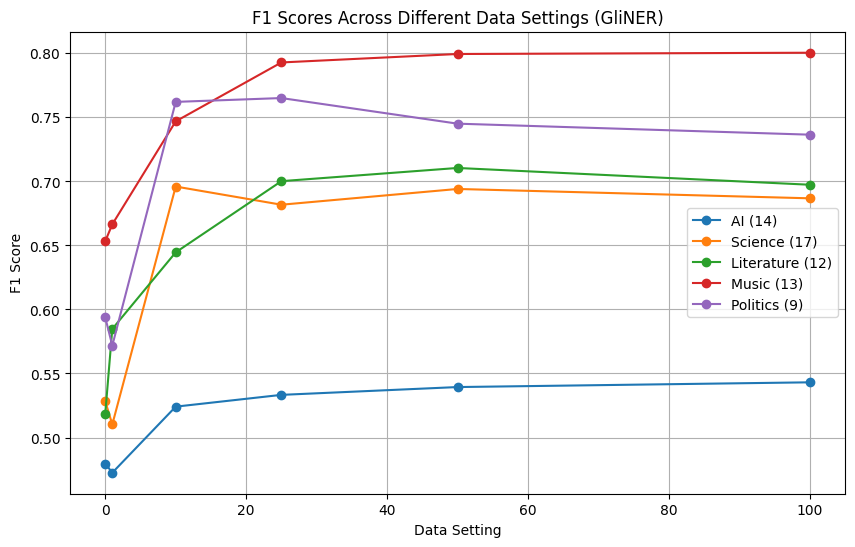

In [12]:
import matplotlib.pyplot as plt

def plot_f1_scores_gliner():
    # Data from the new table
    data_setting = [0, 1, 10, 25, 50, 100]
    f1_scores = {
        "AI (14)": [0.4797, 0.4725, 0.5241, 0.5333, 0.5394, 0.5431],
        "Science (17)": [0.5283, 0.5102, 0.696, 0.6818, 0.6941, 0.6868],
        "Literature (12)": [0.5186, 0.5848, 0.6446, 0.7002, 0.7105, 0.6974],
        "Music (13)": [0.6533, 0.6665, 0.7469, 0.7929, 0.7995, 0.8005],
        "Politics (9)": [0.5938, 0.5718, 0.7621, 0.7651, 0.7451, 0.7365]
    }
    
    # Plot each category
    plt.figure(figsize=(10, 6))
    for category, scores in f1_scores.items():
        plt.plot(data_setting, scores, marker='o', label=category)

    # Labels and title
    plt.xlabel("Data Setting")
    plt.ylabel("F1 Score")
    plt.title("F1 Scores Across Different Data Settings (GliNER)")
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Call the function to plot the graph
plot_f1_scores_gliner()